# Dataset and EDA

1. train.csv
2. test.csv
3. data_description.txt

## Dataset

### Lib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

### Load Data

In [ ]:
train = pd.read_csv('../input/competition/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('../input/competition/house-prices-advanced-regression-techniques/test.csv')
print("Train Shape: ",train.shape)
print("Test Shape: ",test.shape)

Train Shape:  (1460, 81)
Test Shape:  (1459, 80)


In [5]:
print(train.info())


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
print(test.info())

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

## EDA


### Check for NULL values

#### Train Data

In [7]:
print(train.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


<Axes: >

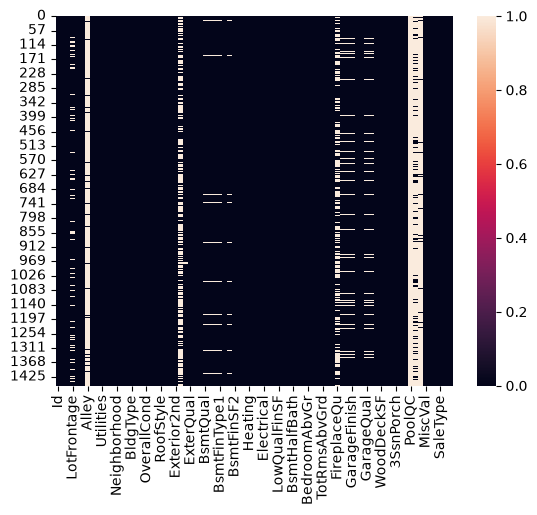

In [8]:
sns.heatmap(train.isnull())

#### Test Data

In [9]:
print(test.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


<Axes: >

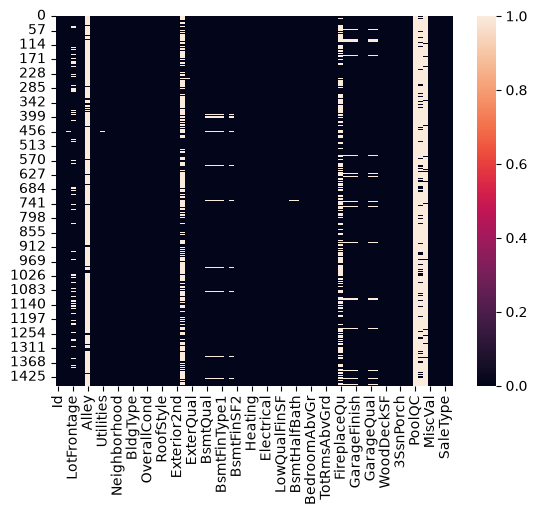

In [10]:
sns.heatmap(test.isnull())

# Handling NULL data

## For train data

In [11]:
cat_col_train = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
    'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
    'GarageQual', 'GarageCond'
]

ncat_col_train = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

for i in cat_col_train:
    train[i] = train[i].fillna(train[i].mode()[0])

for j in ncat_col_train:
    train[j] = train[j].fillna(train[j].mean())

## For test data

In [12]:
cat_col_test = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
    'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'MSZoning', 'Utilities', 'Exterior1st',
    'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType'
]

ncat_col_test = [
    'LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1',
    'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
    'BsmtHalfBath', 'GarageCars', 'GarageArea'
]

for i in cat_col_test:
    test[i] = test[i].fillna(test[i].mode()[0])

for j in ncat_col_test:
    test[j] = test[j].fillna(test[j].mean())

## Drop columns

In [13]:
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']

for k in to_drop:
    train.drop([k], axis=1, inplace=True)
    test.drop([k], axis=1, inplace=True)


<Axes: >

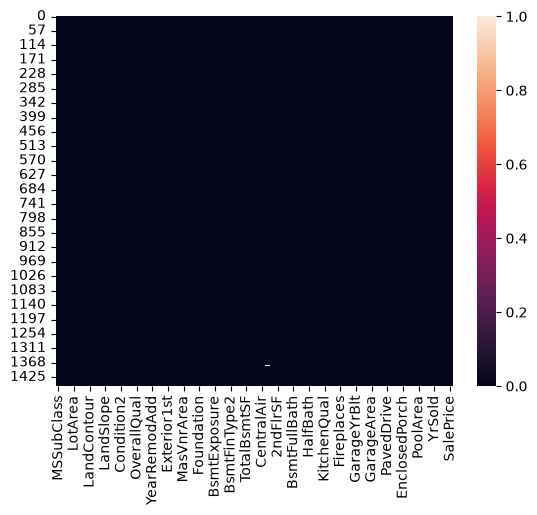

In [14]:

sns.heatmap(train.isnull())

<Axes: >

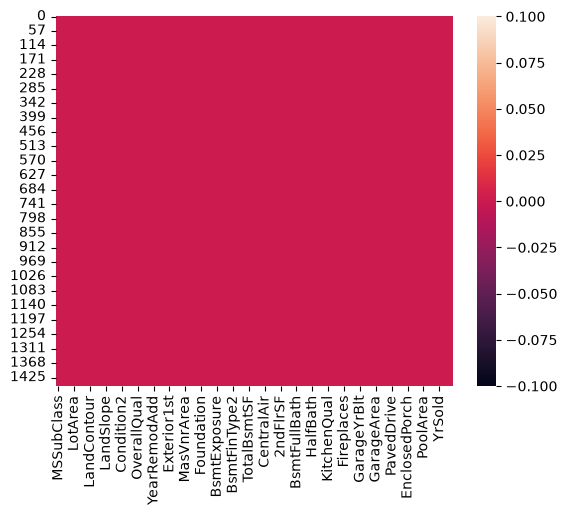

In [15]:
sns.heatmap(test.isnull())


In [16]:

print("Train Shape :", train.shape)
print("Test Shape :", test.shape)

Train Shape : (1460, 76)
Test Shape : (1459, 75)


In [17]:
final_df = pd.concat([train, test], axis=0)
final_df.shape

(2919, 76)

In [18]:
all_cat_col = [
    'MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
    'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
    'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
    'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual',
    'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC',
    'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
    'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'
]

In [19]:
def cat_onehot_encoding(multicol):
    df_final = final_df
    i = 0

    for fields in multicol:
        print(fields)

        df1 = pd.get_dummies(
            final_df[fields],
            drop_first=True
        )

        final_df.drop([fields], axis=1, inplace=True)

        if i == 0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final, df1], axis=1)

        i = i + 1

    df_final = pd.concat([final_df, df_final], axis=1)

    return df_final

final_df = cat_onehot_encoding(all_cat_col)

MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
SaleType
SaleCondition


In [20]:
final_df = final_df.loc[:,~final_df.columns.duplicated()]
final_df.shape

(2919, 176)

In [21]:
df_train = final_df.iloc[:1460, :]
df_test = final_df.iloc[1460:, :]

In [22]:
x_train = df_train.drop(['SalePrice'], axis=1)
y_train = df_train['SalePrice']

x_test = df_test.drop(['SalePrice'], axis=1)